In [1]:
from misc.dataset import get_data
from misc.helpers import normalizeRNA
from models.cncvae import CNCVAE
from models.dec import DEC
from models.metrics import calculate_metrics

data = get_data()
x_num = normalizeRNA(data['rnanp'])   # RNA-seq CPM, min-max scaled
x_bin = data['clin']                  # binary clinical/genotype dummies
print(x_num.shape, x_bin.shape, data['label_classes'])

ae = CNCVAE(input_size=x_num.shape[1] + x_bin.shape[1], ls=16)
ae.build_model()
ae.train(x_num, x_bin)

dec = DEC(ae, n_clusters=2)
y_pred, y_proba, centroids, z = dec.fit(x_num, x_bin, y=data['y'])

acc, ari, nmi = calculate_metrics(data['y'], y_pred)
print('acc={:.3f}  ari={:.3f}  nmi={:.3f}'.format(acc, ari, nmi))

(166, 81) (166, 21) ['MGS1' 'MGS4']
Epoch 7/150 - loss: 0.3066
Epoch 14/150 - loss: 0.1880
Epoch 21/150 - loss: 0.1395
Epoch 28/150 - loss: 0.1182
Epoch 35/150 - loss: 0.1048
Epoch 42/150 - loss: 0.0941
Epoch 49/150 - loss: 0.0826
Epoch 56/150 - loss: 0.0826
Epoch 63/150 - loss: 0.0769
Epoch 70/150 - loss: 0.0711
Epoch 77/150 - loss: 0.0672
Epoch 84/150 - loss: 0.0635
Epoch 91/150 - loss: 0.0626
Epoch 98/150 - loss: 0.0580
Epoch 105/150 - loss: 0.0588
Epoch 112/150 - loss: 0.0602
Epoch 119/150 - loss: 0.0551
Epoch 126/150 - loss: 0.0568
Epoch 133/150 - loss: 0.0572
Epoch 140/150 - loss: 0.0564
Epoch 147/150 - loss: 0.0616
Iter 0: acc = 0.74699, nmi = 0.16743, ari = 0.23789 ; loss=0.00000
Iter 50: acc = 0.75904, nmi = 0.17033, ari = 0.25515 ; loss=0.00000
Iter 100: acc = 0.75904, nmi = 0.17081, ari = 0.25409 ; loss=0.00000
Iter 150: acc = 0.77711, nmi = 0.20564, ari = 0.29309 ; loss=0.00001
Iter 200: acc = 0.76506, nmi = 0.18132, ari = 0.26749 ; loss=0.00000
Iter 250: acc = 0.75904, nmi

In [6]:
import os
import pandas as pd

run_dir = 'results/manual_run'
os.makedirs(run_dir, exist_ok=True)

ae.save_encoder(os.path.join(run_dir, 'encoder_cncvae.pt'))

emb = pd.DataFrame({'sample_id': data['sample_id']})
for j in range(z.shape[1]):
    emb['z{}'.format(j)] = z[:, j]
emb['mgs_level'] = data['label_classes'][data['y']]
emb.to_csv(os.path.join(run_dir, 'cncdec_latent_embedding.csv'), index=False)

import numpy as np
np.savez(os.path.join(run_dir, 'mgs_level.npz'),
         z=z, y_pred=y_pred, y_proba=y_proba, centroids=centroids,
         y=data['y'], sample_id=data['sample_id'], classes=data['label_classes'])
print('Saved to', run_dir)

Saved to results/manual_run


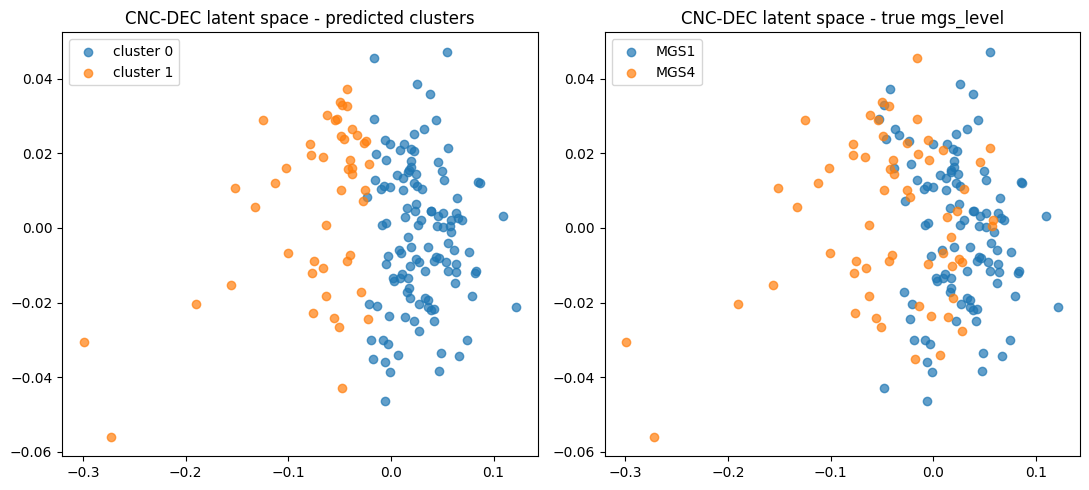

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

proj = PCA(n_components=2, random_state=5192).fit_transform(z)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for c in np.unique(y_pred):
    mask = y_pred == c
    axes[0].scatter(proj[mask, 0], proj[mask, 1], label=f'cluster {c}', alpha=0.7)
axes[0].set_title('CNC-DEC latent space - predicted clusters')
axes[0].legend()

for c, name in enumerate(data['label_classes']):
    mask = data['y'] == c
    axes[1].scatter(proj[mask, 0], proj[mask, 1], label=name, alpha=0.7)
axes[1].set_title('CNC-DEC latent space - true mgs_level')
axes[1].legend()
plt.tight_layout()
plt.show()

mgs_level  MGS1  MGS4
cluster              
0            92    27
1            13    34


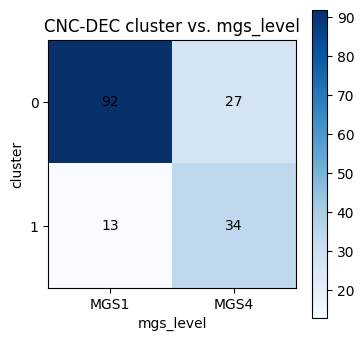

In [4]:
ct = pd.crosstab(pd.Series(y_pred, name='cluster'),
                 pd.Series(data['label_classes'][data['y']], name='mgs_level'))
print(ct)

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(ct.values, cmap='Blues')
ax.set_xticks(range(len(ct.columns))); ax.set_xticklabels(ct.columns)
ax.set_yticks(range(len(ct.index))); ax.set_yticklabels(ct.index)
ax.set_xlabel('mgs_level'); ax.set_ylabel('cluster')
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j, i, ct.values[i, j], ha='center', va='center')
plt.colorbar(im)
plt.title('CNC-DEC cluster vs. mgs_level')
plt.show()

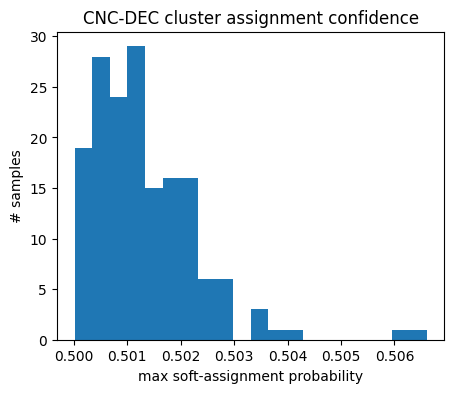

In [5]:
plt.figure(figsize=(5, 4))
plt.hist(y_proba.max(axis=1), bins=20)
plt.xlabel('max soft-assignment probability')
plt.ylabel('# samples')
plt.title('CNC-DEC cluster assignment confidence')
plt.show()